# DSA4262 Group 6 Model Code + Analysis

This notebook contains the code for the NLP severity model used, as well as further analysis of the results. To save time, it is advised not to run the model training code. Instead, load in the model using this link:

This was made in Google Colab. As such, please upload the folder containing the dataset and model weights into Google Drive and mount your drive.

You will also need a huggingface account to access the gated model, mental_RoBERTa

Running the code with the GPU provided by Colab is strongly advised to speed up the code

Please also refer to the report for the error analysis, thank you!

## Import Libraries and Packages

Packages required: numpy, pandas, torch, matplotlib, seaborn, shap, transformers, sklearn

In [ ]:
import os
import gc
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from torch.utils.data import Dataset, DataLoader
import shap
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    RobertaForSequenceClassification
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
)
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_colwidth', None)
SEED = 4262
# ensures any random processes are fixed by seed
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
# check device used to run code. Having cuda is preferrable
def get_device():
    if torch.cuda.is_available():
        print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
        return torch.device("cuda")
    print("Using CPU")
    return torch.device("cpu")

device = get_device()

Using CPU


In [ ]:
from google.colab import drive
# Mount google drive
drive.mount('/content/drive')

Mounted at /content/drive


This notebook assumes that you have mounted your drive. Please download the files and place the folder 'dsa4262' in 'My Drive' before proceeding with the code

In [ ]:
# Set relative file paths for saving of model checkpoints, images.
excel_path = "/content/drive/MyDrive/dsa4262/bullying_data.xlsx"
folder_path = "/content/drive/MyDrive/dsa4262/"
text_col   = "bullying_report"
label_col  = "severity_score"

# if importing dataset directly use this
#df = pd.read_excel('bullying_data.xlsx', sheet_name = 1)

# if using the folder mounted on drive, use this
df = pd.read_excel(excel_path, sheet_name = 1)

df.columns = df.columns.str.strip()
print(f"Columns found : {df.columns.tolist()}")
print(f"Raw shape     : {df.shape}")
print(f"\nNA before:\n{df[[text_col, label_col]].isnull().sum()}")
df = df.dropna(subset=[text_col, label_col])
df[text_col]  = df[text_col].astype(str).str.strip()
df = df[df[text_col] != '']
df[label_col] = df[label_col].astype(int)
print(f"\nNA after:\n{df[[text_col, label_col]].isnull().sum()}")
print(f"Clean shape   : {df.shape}")

Columns found : ['frequency_score', 'bullying_report', 'severity_score']
Raw shape     : (446, 3)

NA before:
bullying_report    0
severity_score     0
dtype: int64

NA after:
bullying_report    0
severity_score     0
dtype: int64
Clean shape   : (446, 3)


Total samples : 446

Class distribution:
severity_score
1    114
2    122
3    107
4    103
Name: count, dtype: int64


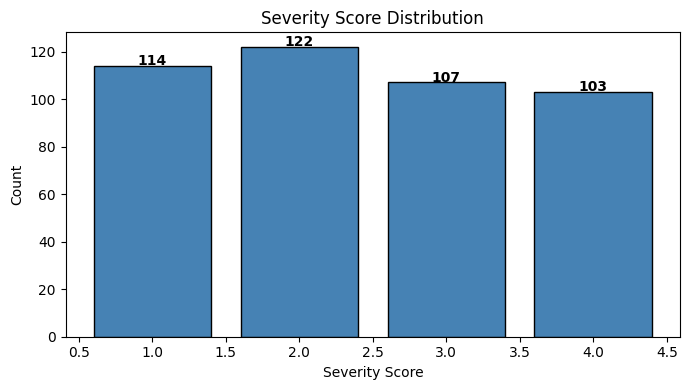

EDA plot saved.


In [ ]:
# EDA of dataset class distribution
print(f"Total samples : {len(df)}")
print(f"\nClass distribution:\n{df[label_col].value_counts().sort_index()}")

counts = df[label_col].value_counts().sort_index()
plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values, color='steelblue', edgecolor='black')
plt.title('Severity Score Distribution')
plt.xlabel('Severity Score')
plt.ylabel('Count')
for i, v in zip(counts.index, counts.values):
    plt.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{folder_path}eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plot saved.")

Based on the above plot, we can tell that the dataset is well-balanced across all 4 severity classes.

### For the following sections, please log in to your hugging face account on Google Colab first. You might need to have the access token from HuggingFace stored on Colab as a secret key first that can be accessed by this notebook.

In [ ]:
from huggingface_hub import login, whoami

# Verify login worked
try:
    info = whoami()
    print("Logged in as:", info['name'])
except Exception as e:
    print("Login failed:", e)

# Model hyperparameters and file paths
CONFIG = {
    "model_name"    : "mental/mental-roberta-base",
    "num_classes"   : 4,
    "batch_size"    : 16,
    "learning_rate" : 2e-5,
    "weight_decay"  : 0.01,
    "num_epochs"    : 10,
    "patience"      : 2,
    "random_state"  : 4262,
    # "max_len"       : 256,
    "test_size"     : 0.2,
    "val_size"      : 0.1,
    "save_dir"      : f"{folder_path}/bullying_severity_model",
    "checkpoint_dir": "/content/checkpoints",
    "n_splits"      : 5,
}

print("Config:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Logged in as: PlacidWombat
Config:
  model_name: mental/mental-roberta-base
  num_classes: 4
  batch_size: 16
  learning_rate: 2e-05
  weight_decay: 0.01
  num_epochs: 10
  patience: 2
  random_state: 4262
  test_size: 0.2
  val_size: 0.1
  save_dir: /content/drive/MyDrive/dsa4262//bullying_severity_model
  checkpoint_dir: /content/checkpoints
  n_splits: 5


── Token Length Analysis ────────────────────────


config.json:   0%|          | 0.00/682 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/327 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

count    446.0
mean      94.5
std       47.4
min       21.0
25%       65.0
50%       83.5
75%      110.8
max      364.0
Name: bullying_report, dtype: float64
95th pct : 182
99th pct : 273
Max      : 364


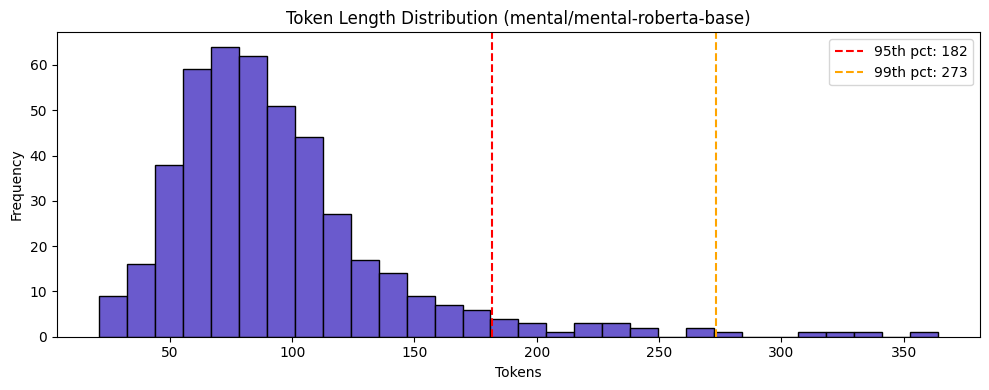

Selected MAX_LEN: 192


In [ ]:
# Distribution of token length of text data in dataset

print("── Token Length Analysis ────────────────────────")
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
token_lengths = df[text_col].apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True))
)
print(token_lengths.describe().round(1))
print(f"95th pct : {token_lengths.quantile(0.95):.0f}")
print(f"99th pct : {token_lengths.quantile(0.99):.0f}")
print(f"Max      : {token_lengths.max()}")

plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=30, color='slateblue', edgecolor='black')
plt.axvline(token_lengths.quantile(0.95), color='red', linestyle='--',
            label=f"95th pct: {token_lengths.quantile(0.95):.0f}")
plt.axvline(token_lengths.quantile(0.99), color='orange', linestyle='--',
            label=f"99th pct: {token_lengths.quantile(0.99):.0f}")
plt.title(f'Token Length Distribution ({CONFIG['model_name']})')
plt.xlabel('Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig(f'{folder_path}/token_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

max_len = min(int(np.ceil(token_lengths.quantile(0.95) / 32) * 32), 512)
print(f"Selected MAX_LEN: {max_len}")

The max length of 192 was chosen because it covers 95% of all samples(95th percentile = 182, rounded up to 192), which means that almost all text descriptions are fully captured without truncation, while avoiding the memory and computational cost of accommodating the extreme outliers beyond the 99th percentile.

In [ ]:
# ── Stratified Train / Test Split ─────────────────────────────────────────
# NOTE: We split ONCE here; the test set is locked away until final evaluation.
train_df, test_df = train_test_split(
    df,
    test_size=CONFIG['test_size'],
    random_state=SEED,
    stratify=df[label_col],
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train size : {len(train_df)}")
print(f"Test  size : {len(test_df)}")
print(f"\nTrain class dist:\n{train_df[label_col].value_counts().sort_index()}")
print(f"\nTest  class dist:\n{test_df[label_col].value_counts().sort_index()}")

Train size : 356
Test  size : 90

Train class dist:
severity_score
1    91
2    97
3    86
4    82
Name: count, dtype: int64

Test  class dist:
severity_score
1    23
2    25
3    21
4    21
Name: count, dtype: int64


In [ ]:
# ── BullyingDataset ────────────────────────────────────────────────────────
class BullyingDataset(Dataset):
    """Tokenises text on-the-fly; labels are 0-indexed (severity - 1)."""
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.tolist()
        self.labels    = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

# 0-index labels (1-4 → 0-3)
train_df['label'] = train_df[label_col] - 1
test_df['label']  = test_df[label_col]  - 1

# ── Metrics ────────────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy" : accuracy_score(labels, preds),
        "f1_macro" : f1_score(labels, preds, average="macro",    zero_division=0),
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
    }

def clear_gpu():
    """Release GPU memory between runs."""
    gc.collect()
    torch.cuda.empty_cache()

print("Dataset class, metrics helper and clear_gpu() defined.")

Dataset class, metrics helper and clear_gpu() defined.


### The next code chunk below trains the RoBERTa model for our use case. No need to run if you are loading in the model checkpoints from the folder.

In [ ]:
# @title
# # ── 5-Fold CV ──────────────────────────────────────────────────────────────
# N_FOLDS   = CONFIG['n_splits']
# EPOCHS    = CONFIG['num_epochs']
# BATCH     = CONFIG['batch_size']
# LR        = CONFIG['learning_rate']
# WD        = CONFIG['weight_decay']
# MAX_LEN   = max_len
# PATIENCE  = CONFIG['patience']
# MODEL_NAME = CONFIG['model_name']
# NUM_LABELS = CONFIG['num_classes']
# SEED      = CONFIG['random_state']

# skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# fold_results = []  # list of dicts

# print(f"{'='*60}")
# print(f"5-Fold CV | lr={LR} | batch={BATCH} | epochs={EPOCHS} | wd={WD} | max_len={MAX_LEN}")
# print(f"{'='*60}")

# for fold, (tr_idx, val_idx) in enumerate(
#     skf.split(train_df[text_col], train_df['label'])
# ):
#     print(f"\n{'─'*50}")
#     print(f"  FOLD {fold+1}/{N_FOLDS}")
#     print(f"{'─'*50}")
#     set_seed(SEED)

#     fold_train = train_df.iloc[tr_idx].reset_index(drop=True)
#     fold_val   = train_df.iloc[val_idx].reset_index(drop=True)

#     tr_ds  = BullyingDataset(fold_train[text_col], fold_train['label'], tokenizer, MAX_LEN)
#     val_ds = BullyingDataset(fold_val[text_col],   fold_val['label'],   tokenizer, MAX_LEN)

#     model = AutoModelForSequenceClassification.from_pretrained(
#         MODEL_NAME, num_labels=NUM_LABELS, ignore_mismatched_sizes=True
#     )

#     steps_per_epoch = max(1, len(tr_ds) // BATCH)

#     args = TrainingArguments(
#         output_dir                  = f"/tmp/fold_{fold}",
#         num_train_epochs            = EPOCHS,
#         per_device_train_batch_size = BATCH,
#         per_device_eval_batch_size  = BATCH * 2,
#         learning_rate               = LR,
#         weight_decay                = WD,
#         warmup_ratio                = 0.1,
#         eval_strategy               = "epoch",
#         save_strategy               = "epoch",
#         load_best_model_at_end      = True,
#         metric_for_best_model       = "f1_macro",
#         greater_is_better           = True,
#         logging_strategy            = "epoch",
#         save_total_limit            = 1,
#         seed                        = SEED,
#         fp16                        = torch.cuda.is_available(),
#         report_to                   = "none",
#         dataloader_num_workers      = 2,
#     )

#     trainer = Trainer(
#         model           = model,
#         args            = args,
#         train_dataset   = tr_ds,
#         eval_dataset    = val_ds,
#         compute_metrics = compute_metrics,
#         processing_class= tokenizer,
#         callbacks       = [EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
#     )

#     trainer.train()

#     # — Collect predictions for this fold —
#     pred_out = trainer.predict(val_ds)
#     preds    = np.argmax(pred_out.predictions, axis=-1)
#     labels   = pred_out.label_ids
#     probs    = torch.softmax(torch.tensor(pred_out.predictions), dim=-1).numpy()

#     fold_f1  = f1_score(labels, preds, average="macro", zero_division=0)
#     fold_acc = accuracy_score(labels, preds)
#     fold_kappa = cohen_kappa_score(labels, preds, weights='quadratic')

#     fold_results.append({
#         "fold"  : fold + 1,
#         "f1"    : fold_f1,
#         "acc"   : fold_acc,
#         "kappa" : fold_kappa,
#         "preds" : preds,
#         "labels": labels,
#         "probs" : probs,
#         "val_idx": val_idx,
#     })

#     print(f"  Fold {fold+1} → Macro-F1: {fold_f1:.4f} | Acc: {fold_acc:.4f} | QWK: {fold_kappa:.4f}")

#     del model, trainer, tr_ds, val_ds
#     clear_gpu()

# # ── Summary ─────────────────────────────────────────────────────────────────
# f1s     = [r['f1']    for r in fold_results]
# accs    = [r['acc']   for r in fold_results]
# kappas  = [r['kappa'] for r in fold_results]

# print(f"\n{'='*60}")
# print("KFOLD CV SUMMARY")
# print(f"{'='*60}")
# print(f"Per-fold Macro-F1 : {[round(f,4) for f in f1s]}")
# print(f"Mean Macro-F1     : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
# print(f"Per-fold Accuracy : {[round(a,4) for a in accs]}")
# print(f"Mean Accuracy     : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
# print(f"Per-fold QWK      : {[round(k,4) for k in kappas]}")
# print(f"Mean QWK          : {np.mean(kappas):.4f} ± {np.std(kappas):.4f}")
# print(f"\nConfig:")
# print(f"  model={MODEL_NAME} | lr={LR} | batch={BATCH} | epochs={EPOCHS} | wd={WD} | max_len={MAX_LEN} | seed={SEED}")

5-Fold CV | lr=2e-05 | batch=16 | epochs=10 | wd=0.01 | max_len=192

──────────────────────────────────────────────────
  FOLD 1/5
──────────────────────────────────────────────────


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: mental/mental-roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

  Fold 5 → Macro-F1: 0.7212 | Acc: 0.7183 | QWK: 0.8305

KFOLD CV SUMMARY
Per-fold Macro-F1 : [0.6955, 0.6642, 0.7644, 0.7298, 0.7212]
Mean Macro-F1     : 0.7150 ± 0.0336
Per-fold Accuracy : [0.6944, 0.6761, 0.7606, 0.7324, 0.7183]
Mean Accuracy     : 0.7164 ± 0.0294
Per-fold QWK      : [np.float64(0.8368), np.float64(0.7985), np.float64(0.8995), np.float64(0.8434), np.float64(0.8305)]
Mean QWK          : 0.8417 ± 0.0327

Config:
  model=mental/mental-roberta-base | lr=2e-05 | batch=16 | epochs=10 | wd=0.01 | max_len=192 | seed=4262


#### This code chunk below visualises the training results. Also no need to run unless retraining the model

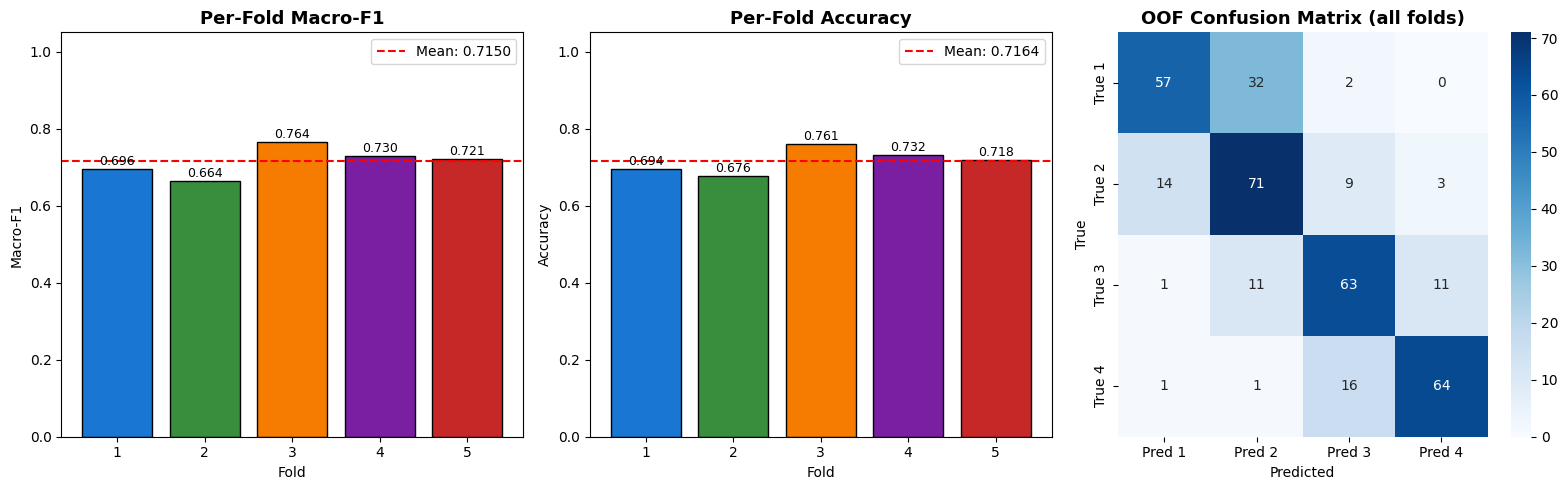

KFold visualisation saved.


In [ ]:
# # ── KFold visualisation ────────────────────────────────────────────────────
# fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# folds = [r['fold'] for r in fold_results]
# palette_cv = ['#1976D2','#388E3C','#F57C00','#7B1FA2','#C62828']

# # — Per-fold bar charts —
# for ax, metric, label in zip(axes[:2],
#                               [f1s, accs],
#                               ["Macro-F1", "Accuracy"]):
#     bars = ax.bar(folds, [round(v,4) for v in metric], color=palette_cv, edgecolor='black')
#     ax.axhline(np.mean(metric), color='red', linestyle='--',
#                label=f"Mean: {np.mean(metric):.4f}")
#     ax.set_title(f"Per-Fold {label}", fontsize=13, fontweight='bold')
#     ax.set_xlabel("Fold"); ax.set_ylabel(label)
#     ax.set_ylim(0, 1.05); ax.legend()
#     for bar, v in zip(bars, metric):
#         ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
#                 f"{v:.3f}", ha='center', fontsize=9)

# # — OOF Confusion Matrix —
# all_preds  = np.concatenate([r['preds']  for r in fold_results])
# all_labels = np.concatenate([r['labels'] for r in fold_results])
# cm = confusion_matrix(all_labels, all_preds)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
#             xticklabels=[f"Pred {i+1}" for i in range(NUM_LABELS)],
#             yticklabels=[f"True {i+1}" for i in range(NUM_LABELS)])
# axes[2].set_title("OOF Confusion Matrix (all folds)", fontsize=13, fontweight='bold')
# axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")

# plt.tight_layout()
# plt.savefig(f'{folder_path}kfold_cv_summary.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("KFold visualisation saved.")

### This runs the model on the test dataset. No need to run unless model is retrained

In [ ]:
# # ── Final model:  ──────────────────────────────
# set_seed(SEED)

# final_train_df, final_val_df = train_test_split(
#     train_df,
#     test_size=CONFIG['val_size'],
#     random_state=SEED,
#     stratify=train_df['label'],
# )
# final_train_df = final_train_df.reset_index(drop=True)
# final_val_df   = final_val_df.reset_index(drop=True)

# print(f"Final train size : {len(final_train_df)}")
# print(f"Final val   size : {len(final_val_df)}")
# print(f"Test        size : {len(test_df)}")

# final_train_ds = BullyingDataset(final_train_df[text_col], final_train_df['label'], tokenizer, MAX_LEN)
# final_val_ds   = BullyingDataset(final_val_df[text_col],   final_val_df['label'],   tokenizer, MAX_LEN)
# test_ds        = BullyingDataset(test_df[text_col],        test_df['label'],         tokenizer, MAX_LEN)

# final_model = AutoModelForSequenceClassification.from_pretrained(
#     MODEL_NAME, num_labels=NUM_LABELS, ignore_mismatched_sizes=True
# )

# final_args = TrainingArguments(
#     output_dir                  = CONFIG['checkpoint_dir'],
#     num_train_epochs            = EPOCHS,
#     per_device_train_batch_size = BATCH,
#     per_device_eval_batch_size  = BATCH * 2,
#     learning_rate               = LR,
#     weight_decay                = WD,
#     warmup_ratio                = 0.1,
#     eval_strategy               = "epoch",
#     save_strategy               = "epoch",
#     load_best_model_at_end      = True,
#     metric_for_best_model       = "f1_macro",
#     greater_is_better           = True,
#     logging_strategy            = "epoch",
#     seed                        = SEED,
#     fp16                        = torch.cuda.is_available(),
#     report_to                   = "none",
#     dataloader_num_workers      = 2,
# )

# final_trainer = Trainer(
#     model           = final_model,
#     args            = final_args,
#     train_dataset   = final_train_ds,
#     eval_dataset    = final_val_ds,
#     compute_metrics = compute_metrics,
#     processing_class= tokenizer,
#     callbacks       = [EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
# )

# print("\nTraining final model...")
# final_trainer.train()
# print("Final training complete.")

Final train size : 320
Final val   size : 36
Test        size : 90


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: mental/mental-roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Training final model...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.395059,1.380398,0.277778,0.108696,0.120773
2,1.376184,1.354275,0.388889,0.282051,0.276353
3,1.196942,1.052246,0.722222,0.720305,0.722348
4,0.802853,0.867934,0.694444,0.691964,0.689319
5,0.524393,0.781546,0.750000,0.735798,0.734661
6,0.345962,0.753034,0.750000,0.753870,0.753010
7,0.213872,0.630202,0.750000,0.756433,0.754678
8,0.142441,0.647403,0.750000,0.747659,0.744227
9,0.094762,0.708261,0.777778,0.777348,0.776211
10,0.061049,0.728466,0.777778,0.775886,0.771012


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Final training complete.


### CODE BLOCK BELOW IS TO LOAD IN SAVED MODEL, PLEASE RUN THIS TO SEE ANALYSIS BELOW

In [ ]:
final_train_df, final_val_df = train_test_split(
    train_df,
    test_size=CONFIG['val_size'],
    random_state=SEED,
    stratify=train_df['label'],
)
final_train_df = final_train_df.reset_index(drop=True)
final_val_df   = final_val_df.reset_index(drop=True)

print(f"Final train size : {len(final_train_df)}")
print(f"Final val   size : {len(final_val_df)}")
print(f"Test        size : {len(test_df)}")

N_FOLDS   = CONFIG['n_splits']
EPOCHS    = CONFIG['num_epochs']
BATCH     = CONFIG['batch_size']
LR        = CONFIG['learning_rate']
WD        = CONFIG['weight_decay']
MAX_LEN   = max_len
PATIENCE  = CONFIG['patience']
MODEL_NAME = CONFIG['model_name']
NUM_LABELS = CONFIG['num_classes']
SEED      = CONFIG['random_state']

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_results = []  # list of dicts
final_train_ds = BullyingDataset(final_train_df[text_col], final_train_df['label'], tokenizer, MAX_LEN)
final_val_ds   = BullyingDataset(final_val_df[text_col],   final_val_df['label'],   tokenizer, MAX_LEN)
test_ds        = BullyingDataset(test_df[text_col],        test_df['label'],         tokenizer, MAX_LEN)

# import saved model
final_model = RobertaForSequenceClassification.from_pretrained(
    f"{folder_path}/bullying_severity_model",
    local_files_only=True  # Optional: ensures it doesn't try to check the internet
).to(device)

final_trainer = Trainer(
    model=final_model,
    processing_class=tokenizer,
    compute_metrics=compute_metrics # Use your existing F1 function
)

Final train size : 320
Final val   size : 36
Test        size : 90


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FINAL TEST-SET RESULTS
  Accuracy        : 0.7556
  Macro-F1        : 0.7550
  Weighted-F1     : 0.7494
  Quadratic WKappa: 0.8549

Classification Report:
              precision    recall  f1-score   support

  Severity 1       0.74      0.74      0.74        23
  Severity 2       0.74      0.56      0.64        25
  Severity 3       0.75      0.86      0.80        21
  Severity 4       0.79      0.90      0.84        21

    accuracy                           0.76        90
   macro avg       0.75      0.77      0.75        90
weighted avg       0.75      0.76      0.75        90



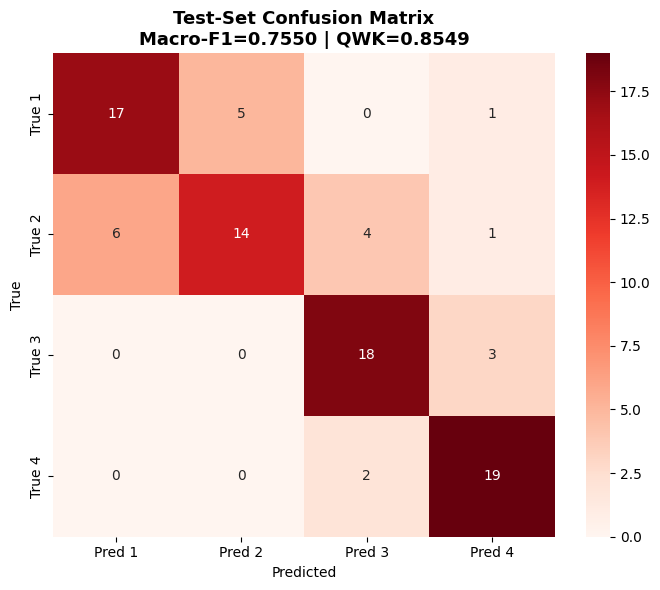

In [ ]:
# ── Test-set evaluation ────────────────────────────────────────────────────
test_output  = final_trainer.predict(test_ds)
test_logits  = test_output.predictions
test_preds   = np.argmax(test_logits, axis=-1)
test_labels  = test_output.label_ids
test_probs   = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()

acc     = accuracy_score(test_labels, test_preds)
f1_mac  = f1_score(test_labels, test_preds, average="macro",    zero_division=0)
f1_wt   = f1_score(test_labels, test_preds, average="weighted", zero_division=0)
qwk     = cohen_kappa_score(test_labels, test_preds, weights='quadratic')

print(f"{'='*55}")
print("FINAL TEST-SET RESULTS")
print(f"{'='*55}")
print(f"  Accuracy        : {acc:.4f}")
print(f"  Macro-F1        : {f1_mac:.4f}")
print(f"  Weighted-F1     : {f1_wt:.4f}")
print(f"  Quadratic WKappa: {qwk:.4f}")
print(f"{'='*55}")
print("\nClassification Report:")
print(classification_report(test_labels, test_preds,
      target_names=[f"Severity {i+1}" for i in range(NUM_LABELS)], zero_division=0))

# — Confusion matrix plot —
fig, ax = plt.subplots(figsize=(7, 6))
cm_test = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=[f"Pred {i+1}" for i in range(NUM_LABELS)],
            yticklabels=[f"True {i+1}" for i in range(NUM_LABELS)])
ax.set_title(f"Test-Set Confusion Matrix\nMacro-F1={f1_mac:.4f} | QWK={qwk:.4f}",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(f'{folder_path}test_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

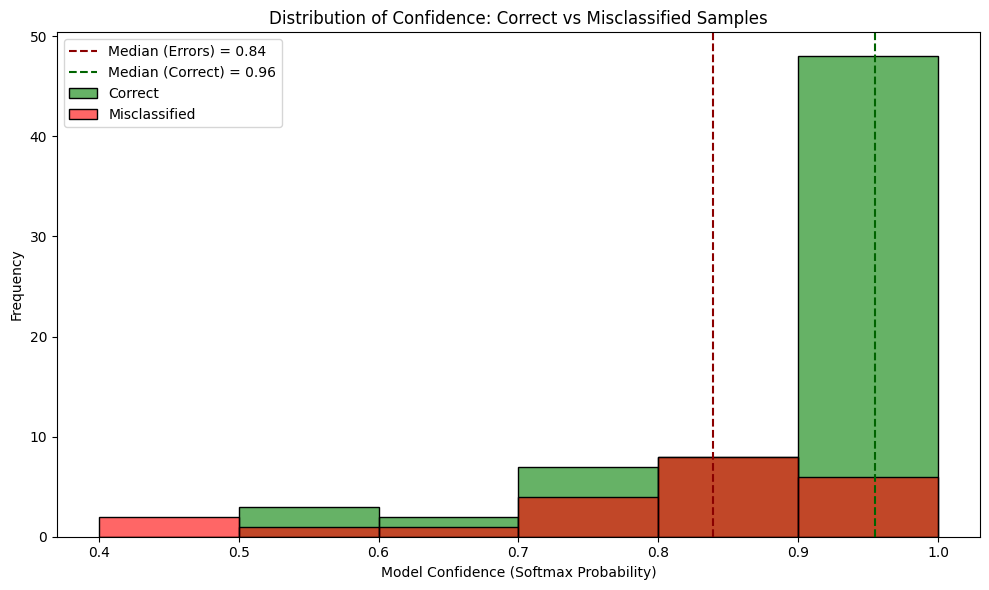

MEDIAN CONFIDENCE SAMPLE — ERRORS (confidence=0.84)

MEDIAN CONFIDENCE SAMPLE — CORRECT (confidence=0.96)


In [ ]:
# Error Analysis code
# Map data using the .texts attribute from your BullyingDataset instance
subset = {
    'text': test_ds.texts,
    'true_label': test_labels + 1,
    'pred_label': test_preds + 1,
    'confidence': [test_probs[i, pred] for i, pred in enumerate(test_preds)]
}

# Create DataFrame from model output
df_analysis = pd.DataFrame(subset)

# Filter for misclassifications and correct predictions
df_errors = df_analysis[df_analysis['true_label'] != df_analysis['pred_label']].copy()
df_correct = df_analysis[df_analysis['true_label'] == df_analysis['pred_label']].copy()

# Sort errors by confidence
df_errors = df_errors.sort_values(by='confidence', ascending=False)
df_errors['error_distance'] = (df_errors['true_label'] - df_errors['pred_label']).abs()
df_errors['text_len'] = df_errors['text'].apply(len)

# Compute medians
median_errors = df_errors['confidence'].median()
median_correct = df_correct['confidence'].median()

# Find the sample closest to each median
median_error_text = df_errors.loc[(df_errors['confidence'] - median_errors).abs().idxmin(), 'text']
median_correct_text = df_correct.loc[(df_correct['confidence'] - median_correct).abs().idxmin(), 'text']

# Confidence Distribution for Errors vs Correct
plt.figure(figsize=(10, 6))

sns.histplot(df_correct['confidence'], bins=np.arange(0.4, 1.1, 0.1),
             color='green', alpha=0.6, label='Correct')
sns.histplot(df_errors['confidence'], bins=np.arange(0.4, 1.1, 0.1),
             color='red', alpha=0.6, label='Misclassified')

# Mark medians
plt.axvline(median_errors, color='darkred', linestyle='--', linewidth=1.5, label=f'Median (Errors) = {median_errors:.2f}')
plt.axvline(median_correct, color='darkgreen', linestyle='--', linewidth=1.5, label=f'Median (Correct) = {median_correct:.2f}')

plt.title('Distribution of Confidence: Correct vs Misclassified Samples')
plt.xlabel('Model Confidence (Softmax Probability)')
plt.ylabel('Frequency')
plt.xticks(np.arange(0.4, 1.1, 0.1))
plt.legend()
plt.tight_layout()
plt.savefig(f'{folder_path}confidence.png', dpi=150, bbox_inches='tight')
plt.show()

# Display median texts
print("=" * 70)
print(f"MEDIAN CONFIDENCE SAMPLE — ERRORS (confidence={median_errors:.2f})")
print("=" * 70)
print()
print("=" * 70)
print(f"MEDIAN CONFIDENCE SAMPLE — CORRECT (confidence={median_correct:.2f})")
print("=" * 70)

# Extract 2 high-confidence errors and 2 low-confidence errors for analysis
high_confidence_errors = df_errors.nlargest(2, 'confidence')
low_confidence_errors = df_errors.nsmallest(2, 'confidence')

# Find cases where the model was way off (e.g., missed by 2+ severity levels)
major_misses = df_errors[df_errors['error_distance'] >= 2].sort_values(by='confidence', ascending=False)


count     22.0
mean     105.7
std       54.6
min       28.0
25%       70.2
50%       94.0
75%      122.0
max      233.0
Name: text, dtype: float64
95th pct : 225
99th pct : 232
Max      : 233


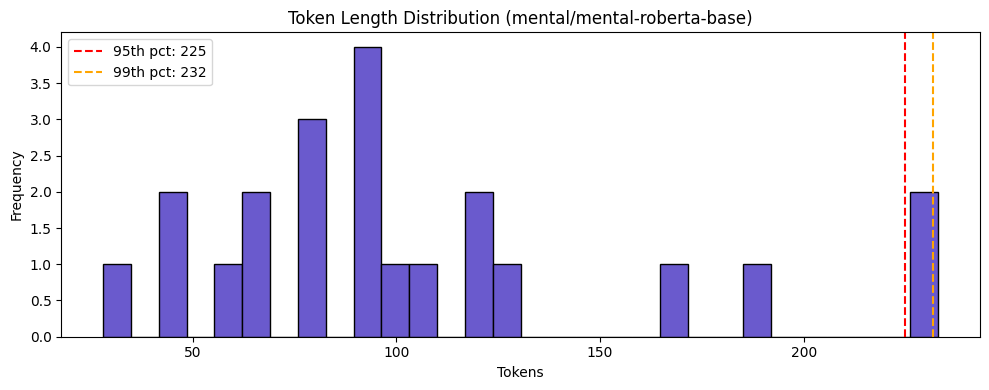

In [ ]:
# Distribution of token lengths for error cases
error_token_lengths = df_errors['text'].apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True))
)
print(error_token_lengths.describe().round(1))
print(f"95th pct : {error_token_lengths.quantile(0.95):.0f}")
print(f"99th pct : {error_token_lengths.quantile(0.99):.0f}")
print(f"Max      : {error_token_lengths.max()}")

plt.figure(figsize=(10, 4))
plt.hist(error_token_lengths, bins=30, color='slateblue', edgecolor='black')
plt.axvline(error_token_lengths.quantile(0.95), color='red', linestyle='--',
            label=f"95th pct: {error_token_lengths.quantile(0.95):.0f}")
plt.axvline(error_token_lengths.quantile(0.99), color='orange', linestyle='--',
            label=f"99th pct: {error_token_lengths.quantile(0.99):.0f}")
plt.title(f'Token Length Distribution ({CONFIG['model_name']})')
plt.xlabel('Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig(f'{folder_path}/errors_token_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --Code to set up SHAP functionality--
# Define the prediction function using final_trainer.model
def predict_probs(texts):
    # Force everything into a list of strings
    if isinstance(texts, str):
        texts = [texts]
    elif isinstance(texts, np.ndarray):
        texts = texts.tolist()

    # Ensure every element is a string (handles potential NaNs or objects)
    texts = [str(t) for t in texts]

    model_internal = final_trainer.model
    model_internal.eval()

    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256 # Increased for long narrative form reports
    ).to(model_internal.device)

    with torch.no_grad():
        outputs = model_internal(**inputs)

    return torch.softmax(outputs.logits, dim=-1).cpu().numpy()

# Initialize the Explainer with the updated function
explainer = shap.Explainer(predict_probs, tokenizer)

In [ ]:
# get SHAP values for entire test dataset
test_texts_list = df_analysis['text'].astype(str).tolist()
print(f"Generating SHAP values for {len(test_texts_list)} error cases...")
shap_values_test = explainer(test_texts_list)

Generating SHAP values for 90 error cases...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   1%|          | 1/90 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   3%|▎         | 3/90 [04:13<1:33:50, 64.72s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   3%|▎         | 3/90 [04:50<3:30:53, 145.45s/it]


KeyboardInterrupt: 

Generating SHAP values for 22 error cases...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  27%|██▋       | 6/22 [00:17<00:40,  2.52s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  82%|████████▏ | 18/22 [00:57<00:12,  3.03s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  86%|████████▋ | 19/22 [01:02<00:11,  3.67s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 23it [01:17,  3.87s/it]


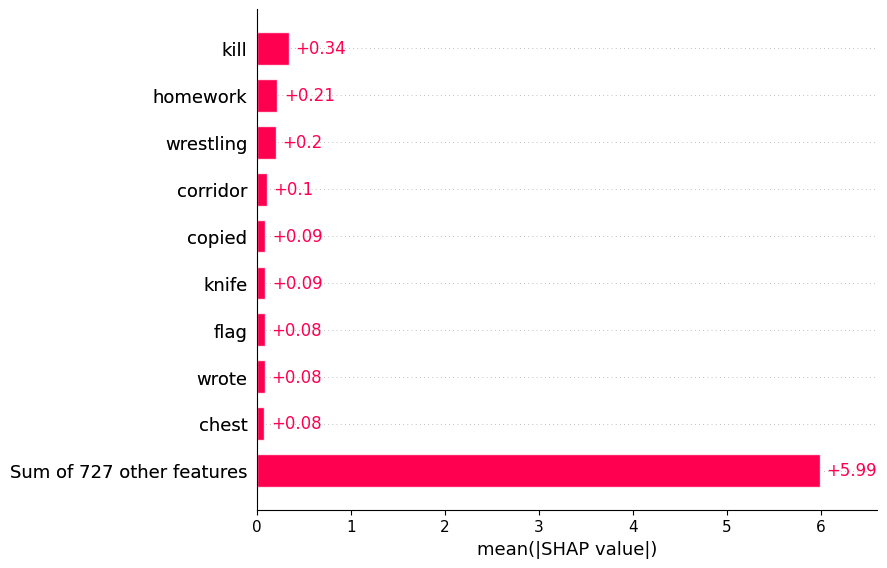

In [ ]:
# Get SHAP values for error cases only
error_texts_list = df_errors['text'].astype(str).tolist()
print(f"Generating SHAP values for {len(error_texts_list)} error cases...")
shap_values_errors = explainer(error_texts_list)
#pred_class_idx = 1
#shap.plots.bar(shap_values_errors[:, :, pred_class_idx].abs.mean(0), max_display=10)

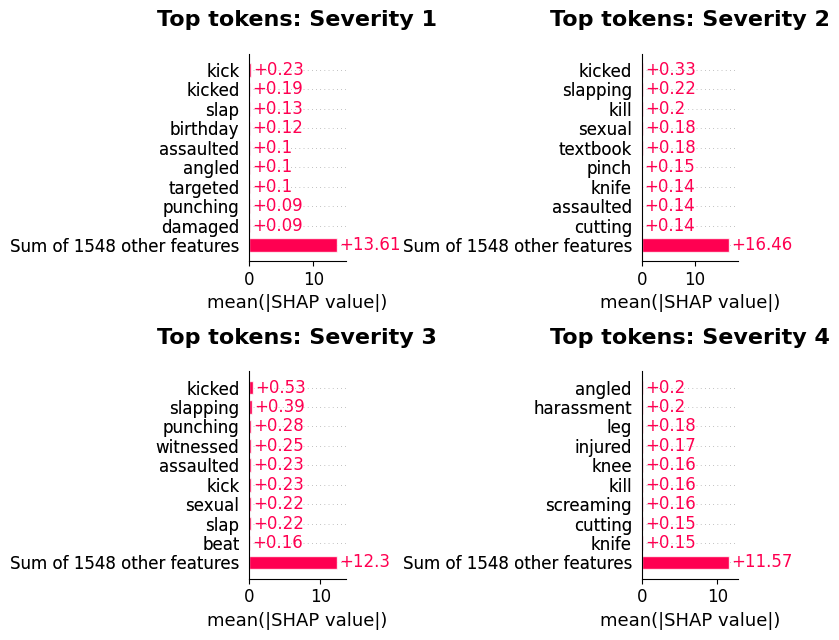

In [ ]:
# SHAP analysis of entire test dataset for all severity levels
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

severity_labels = ["Severity 1", "Severity 2", "Severity 3", "Severity 4"]

for i, label in enumerate(severity_labels):
    # Set the current active axis for SHAP
    plt.sca(axes[i])

    # Generate the bar plot for the specific severity class
    # Use the 'ax' parameter if your version of SHAP supports it,
    # otherwise plt.sca() handles the targeting.
    shap.plots.bar(
        shap_values_test[:, :, i].abs.mean(0),
        max_display=10,
        show=False
    )

    # Explicitly set the title for this subplot
    axes[i].set_title(f"Top tokens: {label}", fontsize=16, fontweight='bold', pad=20)

    # Adjust label sizes for better readability in reports
    axes[i].tick_params(axis='both', which='major', labelsize=12)

# Final layout adjustments to prevent label clipping
plt.tight_layout()
plt.show()

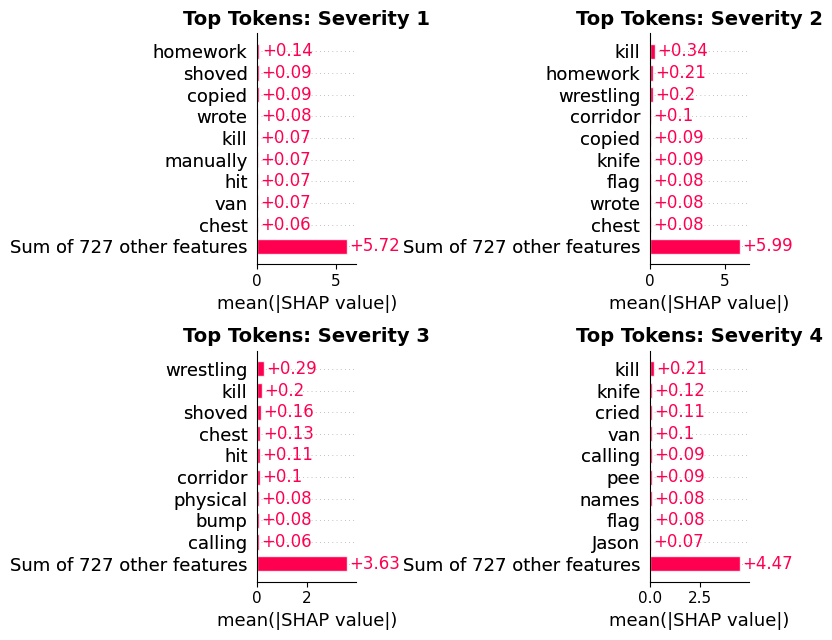

In [ ]:
# SHAP analysis of errors for all severity levels
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

severity_labels = ["Severity 1", "Severity 2", "Severity 3", "Severity 4"]

for i, label in enumerate(severity_labels):
    # Select the current axis
    plt.sca(axes[i])

    # Generate bar plot for that specific axis
    # we use .abs.mean(0) to show the global magnitude for that class
    shap.plots.bar(
        shap_values_errors[:, :, i].abs.mean(0),
        max_display=10,
        show=False
    )

    # titles and labels for the grid
    axes[i].set_title(f"Top Tokens: {label}", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

The second case has a token length of: 94


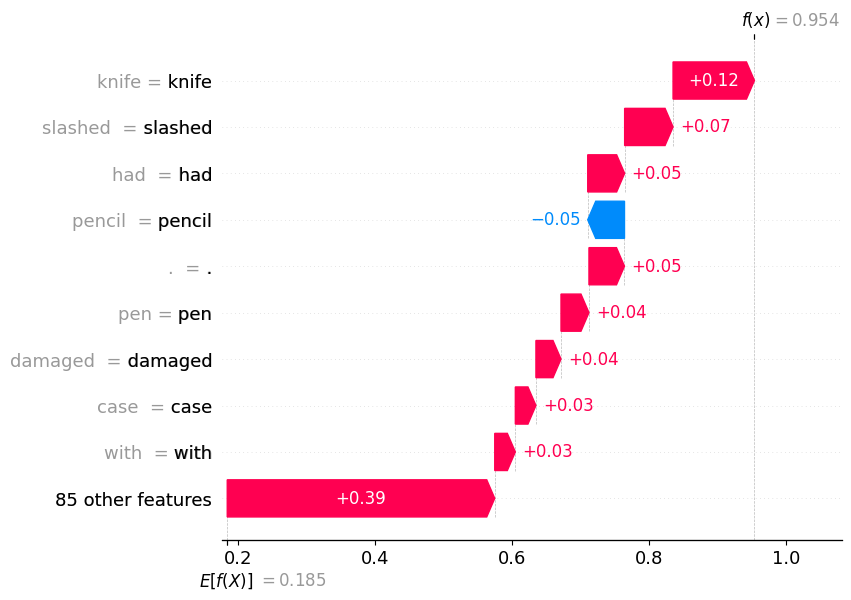

In [ ]:
# SHAP plot for 1st case where severity is misclassified by at least 2 levels.
mm_error_token_lengths = major_misses['text'].apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True))
)
print("The second case has a token length of: " + str(mm_error_token_lengths.iat[0]))
shap.plots.waterfall(explainer(major_misses['text'])[0, :, 3])

The second case has a token length of: 28


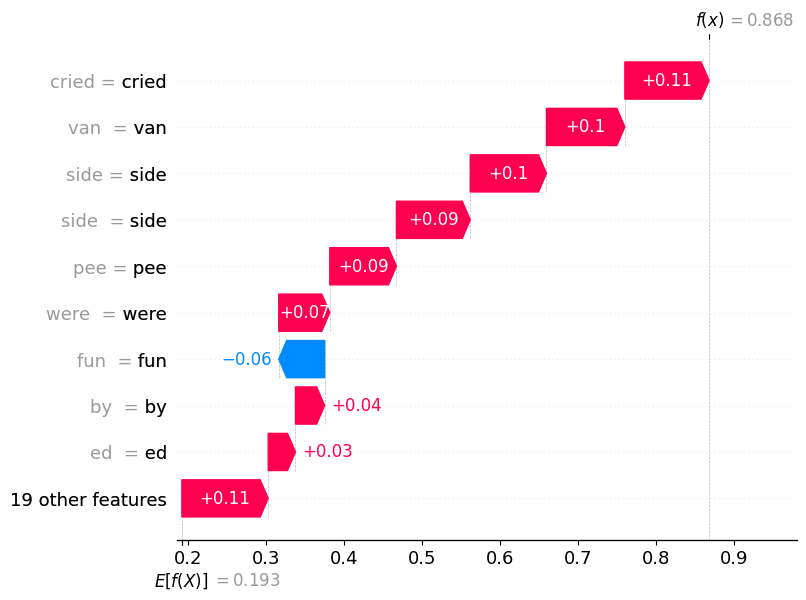

In [ ]:
# # SHAP plot for 2nd case where severity is misclassified by at least 2 levels.
print("The second case has a token length of: " + str(mm_error_token_lengths.iat[1]))
shap.plots.waterfall(explainer(major_misses['text'])[1, :, 3])

In [ ]:
# ── Save final model (optional) ────────────────────────────────────────────
# Uncomment below if you have Drive space.

# save_path = CONFIG['save_dir']
# final_trainer.save_model(save_path)
# tokenizer.save_pretrained(save_path)
# print(f"Model saved to {save_path}")

# # ── Clean up GPU memory ─────────────────────────────────────────────────────
# del final_model, final_trainer, final_train_ds, final_val_ds, test_ds
# clear_gpu()
# print("GPU cache cleared. All done!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/dsa4262//bullying_severity_model
GPU cache cleared. All done!
